## Block 3: Exact Counts, Big-Oh, and Lower Bounds
   Let's shift into the mathematical heart of algorithm analysis. When we ask
   "how fast is this algortihm?", we can answer at three different levels of 
   zoom: the exact count, the asymptotic trend, and the theoretical floor.


1. Exact Counts (The "Tournament" Logic)
   Sometimes we need to know the exact number of operations. Instead of tracing
   code line-by-line, use physical analogies.

   Think of finding the maximum element in an unordered list of $n$ elements as 
   a tennis tournament. For one element to be crowned the absolute maximum, 
   every other element must lose exactly one match. Since there are $n - 1$
   losers, there must be exactly $n - 1$ matches (comparisons) played.


2. Asymptotic Order (Big-Oh && Theta)
   When $n$ gets massive (think millions), the exact count stops mattering. We
   zoom out and look at the dominant trend.
      * If your exact count is $f(n) = 6n^2 - n + 5$, the $-n$ and $+5$ are
        irrelevant at scale. Even the $6$ doesn't fundamentally change the shape
        of the growth curve.
      * $O(g(n))$ (Big-Oh): This is an UPPER BOUND. It means your function grows
        no faster than $c \cdot g(n)$ for some constant $c$, once $n$ is large
        enough.
      * $\Theta(g(n))$ (Theta): This means the functions bound each other. They
        grow at the exact same fundamental rate. A function like $6n^2 - n + 5$
        is $\Theta(n^2)$.


3. Lower-Bound Reasoning (The Theoretical Floor)
   How do we prove that no algortihm in the universe could ever solve a problem
   faster than a certain speed? We look at the problem's structure, not the code
      * THE "LEAVES" ARGUMENT: For sorting $n$ items, there are $n!$ possible
        correct permutations. If we draw a decision tree, it MUST have at least
        $n!$ leaves. Since a binary tree of depth $d$ has at most $2^d$ leaves,
        the depth (worst-case comparisons) MUST be at least 
        $\lceil \log_2(n!) \rceil$.
      * THE "MOVEMENT" ARGUMENT: For counting swaps, look at how far elements
        need to travel. If an element is at index 0 but needs to be at index
        $n - 1$, a single adjacent swap only moves it 1 space.  
           - Each adjacent swap moves one element +1 position and another -1
             position. The total "displacement" of all elements is 6. But each
             swap reduces total displacement by EXACTLY 2 (one element gets
             1 closer, the other... might get further or closer).

             More precisely: the number of adjacent swaps needed = the number of
             INVERSIONS (pairs where a larger element sits before a smaller
             one). This is 4 for this array.



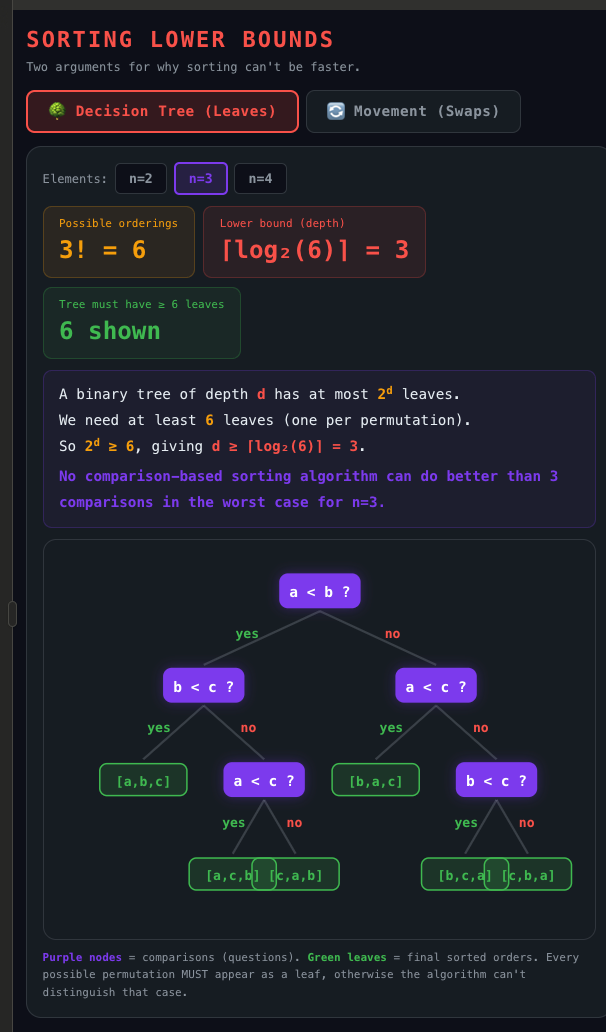

In [ ]:
---

   The workflow demonstrated in the proof sketch bridges the gap between 
   empirical observation (the table of values) and the rigorous mathematical
   definitions of asymptotic complexity.


1. The Formal Definitions
   To prove the relationship between f(n) and g(n), the workflow relies on the
   strict definitions of Big-Oh and Theta:
      * Big-Oh ($O$): A function $f$ is $O(g)$ if there exists a positive 
        constant $c \in \mathbf{R^+}$ and an integer threshold $m \in \mathbf{N}$
        such that for all n >= m, we have $f(n) \leq c \cdot g(n)$.
      * Theta ($\Theta$): A function $f$ is $\Theta(g)$ if and only if $f$ is
        $O(g)$ and $g$ is $O(f)$.


2. The Limit Method (Finding the Ratio)
   Finding the constants $c$ and $m$ through pure algebra can be tedious. The
   proof sketch bypasses this by using the LIMIT OF THE RATIO.

   To determine how $f(n)$ grows relative to $g(n)$ as $n$ becomes arbitrarily
   large, we divide the two functions and take the limit as $n \to \infty$:

   $$\lim_{n \to \infty} \frac{f(n)}{g(n)} = \lim_{n \to \infty} \frac{6n^2 - n + 5}{0.25n^2 + 13n - 2}$$

   To evaluate this rigorously, divide the numerator and the denominator by the
   highest power of n...

   As $n$ approaches infinity, any term divided by $n$ or $n^2$ shrinks to 
   exactly 0. The lower-order terms vanish completely, leaving only the 
   coefficients of the dominant n^2 terms:

      ...


3. CONNECTING THE LIMIT TO THE CONSTANTS $c$ and $n_0$
   Because the limit converges to exactly 24, it mathematically guarantees that
   as $n$ gets larger, the value of $f(n)$ will become virtually 
   indistinguishable from $24 \cdot g(n)$

   This conveergence is what the table physically demonstrates. At $n = 1$, the
   ratio $f / g$ is 11.25. By $n = 100$, the ratio has climbed to 15.77, and it
   will continue climbing asymptotically until it flattens out at exactly 24.

   The limit gives you the exact blueprint for choosing the constants required
   by the formal definition:

   1. CHOOSING $c$: To satisfy $f(n) \leq c \cdot g(n)$, you simply choose any
      constant $c$ strictly greater than the limit. The proof sketch chooses
      $c = 25$.
   2. CHOOSING $m$: Because 25 > 24, there is mathematically guaraneed to be a
      crossover point (the threshold $m$) where $25 \cdot g(n)$ permanently 
      overtakes f(n). You do not even need to calculate the exact integer value
      of $m$; proving that the limit is 25 is sufficient prove that a valid $m$
      exists for $c = 25$.

   This formally satisfies the condition that $f \in O(g)$ 


4. PROVING $\Theta$ (The Reverse Bound)
   To prove they belong to the same $\Theta$ class, the workflow repeats the 
   exact same limit process in reverse to prove $g \in O(f)$:

   $$\lim_{n \to \infty} \frac{g(n)}{f(n)} = \frac{0.25}{6} \approx 0.0417$$

   Because this ratio converges to a finite positive number, we again know a 
   bounding constant exists. Choose any constant c > 0.0417 (the sketch
   suggests c = 2) mathematically guarantees that $g(n) \leq 2 \cdot f(n)$ for
   all $n$ past some threshold $m$.

   ...

           

---

## Block 4: Insertion Sort Patterns, Recurrences, and the Master Theorem
   ... mastering how to count operations without getting lost in the weeds.
   When dealing with sorting algorithms, you should rarely trace code 
   line-by-line; instead, look for structural patterns. When dealing with 
   recursive algorithms, you use the Master Theorem.


1. Insertion Sort Patterns (Count by Structure)
   Insertion sort builds a sorted "safe zone" at the front of the list. When
   evaluating a new element, it steps backward through the safe zone until it
   finds a smaller element.

   - THE GOLDEN RULE FOR COUNTING: The number of comparisons an element takes to 
     be inserted is exactly THE NUMBER OF POSITIONS IT MOVES LEFT + 1 (unless it
     moves all the way to index 0, in which case it's jsut the number of
      positions it moved).
   - Instead of tracing a massive array, write out the list conceptually 
     (e.g., $[n, 2, 3, ..., n-1, 1]$), calculate the comparisons for a generic
     element $i$ in the middle, and sum them up using basic arithmetic series.


2. Recurrence Relations, $a, b$ and $f(n)$
   Divide-and-conquer algorithms (like MergeSort or Strassen's) split a problem
   into smaller chunks. You model their running time $T(n)$ with the equation:
   $$T(n) = aT(n/b) + f(n)$$     
      - $a$: The number of sub-problems you spawn.
      - $b$: The factor by which you shrink the input (e.g., $b = 2$ means
        cutting the array in half).
      - $f(n)$: The "overhead" work done at the current level to split the data
        or combine the results.


3. The Master Theorem && The Critical Exponent ($E$)
   To solve the recurrence instantly, calculate the CRITICAL EXPONENT:           


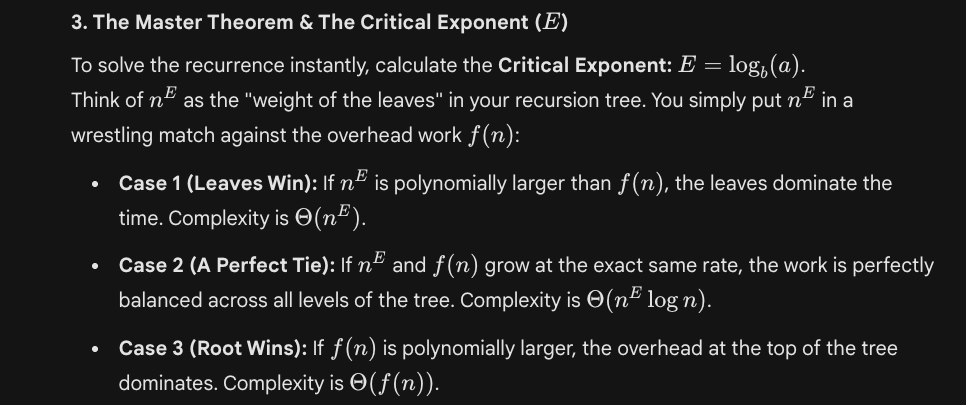

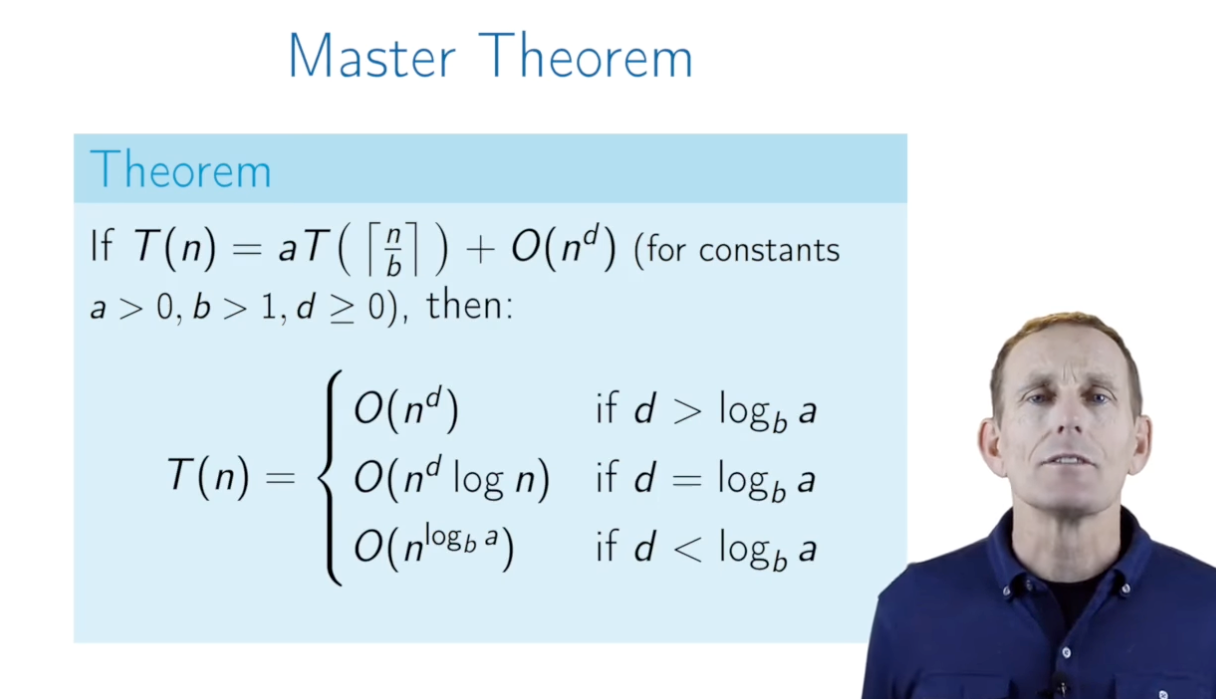

---

   THE SETUP BOX at the top explains exacty what "swapped ends" mean...

   STEP THROUGH THE ANIMATION -- every single comparison gets its own step with
   a detailed explanation:

   - Round i=1: Element 2 meets the big intruder 5. 2 < 5 -> swap! The big
     intruder slides right. Only 1 COMPARISON needed (2 has nobody else to
     check aaginst).
   - Round i=2, i=3: Each middle element (3, then 4) enters the sorted section
     and hits the big intruder. It swaps past the intruder, then checks the 
     element below -- that one is smaller, so it STOPS. Each round costs 2
     COMPARISONS, 1 SWAP. The stop comparison is the "extra" one that doesn't
     cause a swap -- that's why c > s for these rounds.
   - ROUND i=n-1 (the last round): Element 1 -- the tiny intruder -- enters and
     sinks ALL the way to position 0. Every comparison is a swap (1 is smaller
     than everything). It HITS THE FLOOR with no stop comparison. Costs $n - 1$
     comparisons, $n - 1$ swaps.